In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV

from sklearn.metrics import accuracy_score,confusion_matrix,roc_auc_score,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:

file = r"D:\New folder (3)\ml-project\CTG.xls"
df = pd.read_excel(file, sheet_name="Raw Data", engine="xlrd")
df.head()

,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Variab10.txt,1996-12-01,CTG0001.txt,240.0,357.0,120.0,120.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
2,Fmcs_1.txt,1996-05-03,CTG0002.txt,5.0,632.0,132.0,132.0,4.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,Fmcs_1.txt,1996-05-03,CTG0003.txt,177.0,779.0,133.0,133.0,2.0,0.0,5.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,Fmcs_1.txt,1996-05-03,CTG0004.txt,411.0,1192.0,134.0,134.0,2.0,0.0,6.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0


In [3]:
df.columns

Index(['FileName', 'Date', 'SegFile', 'b', 'e', 'LBE', 'LB', 'AC', 'FM', 'UC',
       'ASTV', 'MSTV', 'ALTV', 'MLTV', 'DL', 'DS', 'DP', 'DR', 'Width', 'Min',
       'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance',
       'Tendency', 'A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS', 'SUSP',
       'CLASS', 'NSP'],
      dtype='object')

In [4]:
df.shape

(2130, 40)

In [5]:
df.dtypes

FileName            object
Date        datetime64[ns]
SegFile             object
b                  float64
e                  float64
LBE                float64
LB                 float64
AC                 float64
FM                 float64
UC                 float64
ASTV               float64
MSTV               float64
ALTV               float64
MLTV               float64
DL                 float64
DS                 float64
DP                 float64
DR                 float64
Width              float64
Min                float64
Max                float64
Nmax               float64
Nzeros             float64
Mode               float64
Mean               float64
Median             float64
Variance           float64
Tendency           float64
A                  float64
B                  float64
C                  float64
D                  float64
E                  float64
AD                 float64
DE                 float64
LD                 float64
FS                 float64
S

In [6]:
df['SegFile'].head()

0            NaN
1    CTG0001.txt
2    CTG0002.txt
3    CTG0003.txt
4    CTG0004.txt
Name: SegFile, dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2130 entries, 0 to 2129
Data columns (total 40 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   FileName  2126 non-null   object        
 1   Date      2126 non-null   datetime64[ns]
 2   SegFile   2126 non-null   object        
 3   b         2126 non-null   float64       
 4   e         2126 non-null   float64       
 5   LBE       2126 non-null   float64       
 6   LB        2126 non-null   float64       
 7   AC        2126 non-null   float64       
 8   FM        2127 non-null   float64       
 9   UC        2127 non-null   float64       
 10  ASTV      2127 non-null   float64       
 11  MSTV      2127 non-null   float64       
 12  ALTV      2127 non-null   float64       
 13  MLTV      2127 non-null   float64       
 14  DL        2128 non-null   float64       
 15  DS        2128 non-null   float64       
 16  DP        2128 non-null   float64       
 17  DR        2128

In [8]:
df.describe()

,Date,b,e,LBE,LB,AC,FM,UC,ASTV,MSTV,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
count,2126,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2127.000000,2127.000000,2127.000000,2127.000000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,1996-04-22 16:59:22.746942592,878.439793,1702.877234,133.303857,133.303857,2.722484,7.503056,3.669017,47.008933,1.335449,...,0.024929,0.038100,0.033866,0.156162,0.118532,0.050329,0.032455,0.092662,4.509878,1.304327
min,1980-01-04 00:00:00,0.000000,287.000000,106.000000,106.000000,0.000000,0.000000,0.000000,12.000000,0.200000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,1996-05-02 00:00:00,55.000000,1009.000000,126.000000,126.000000,0.000000,0.000000,1.000000,32.000000,0.700000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000
50%,1996-08-21 00:00:00,538.000000,1241.000000,133.000000,133.000000,1.000000,0.000000,3.000000,49.000000,1.200000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000
75%,1997-03-20 00:00:00,1521.000000,2434.750000,140.000000,140.000000,4.000000,2.000000,5.000000,61.000000,1.700000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,1.000000
max,1998-06-06 00:00:00,3296.000000,3599.000000,160.000000,160.000000,26.000000,564.000000,23.000000,87.000000,7.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10.000000,3.000000
std,NaN,894.084748,930.919143,9.840844,9.840844,3.560850,39.030452,2.877148,17.210648,0.891543,...,0.155947,0.191482,0.180928,0.363094,0.323314,0.218675,0.177248,0.290027,3.026883,0.614377


In [9]:
df.isnull().sum().sort_values(ascending=False)

FileName    4
Date        4
SegFile     4
b           4
e           4
LBE         4
LB          4
AC          4
Max         4
Nmax        4
Mode        4
Nzeros      4
Width       4
Min         4
AD          4
E           4
D           4
C           4
B           4
A           4
Tendency    4
Variance    4
Median      4
Mean        4
FS          4
SUSP        4
DE          4
LD          4
CLASS       4
NSP         4
UC          3
FM          3
ALTV        3
MLTV        3
ASTV        3
MSTV        3
DR          2
DP          2
DL          2
DS          2
dtype: int64

In [10]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [11]:
cat_cols = df.select_dtypes(include="object").columns

df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [12]:
df = df.drop_duplicates()

In [13]:
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower,
                np.where(df[col] > upper, upper, df[col]))
    return df



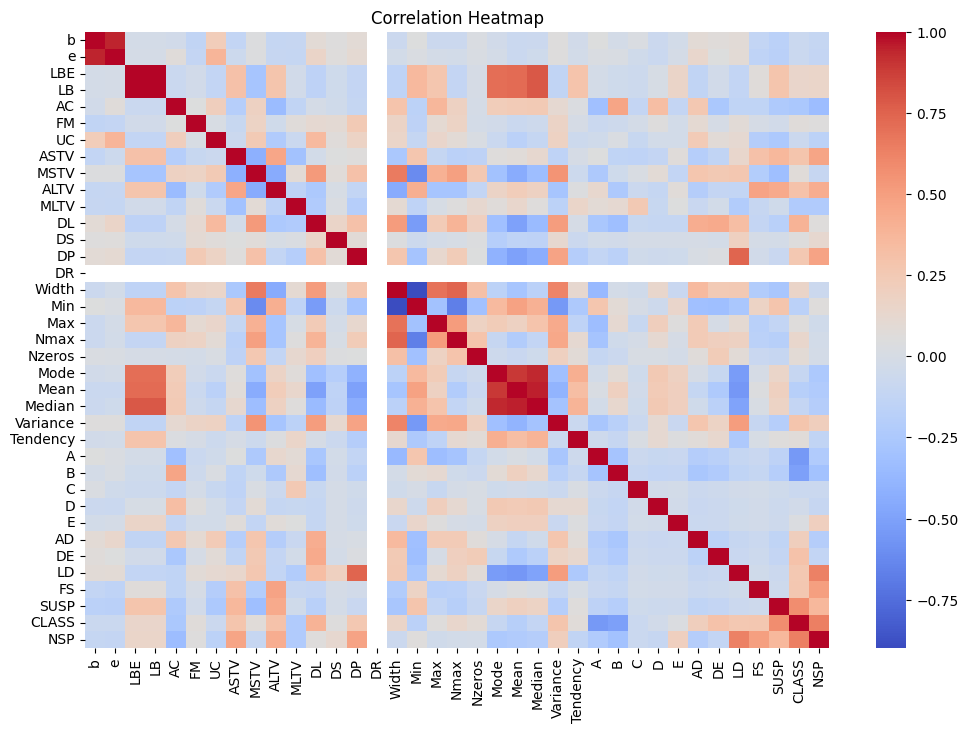

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [15]:
skewness = df.skew(numeric_only=True).sort_values(ascending=False)
print(skewness)

DS          16.228833
FM           9.458133
C            6.101554
FS           5.283317
E            5.160243
D            4.831571
DP           4.287248
LD           4.118824
Nzeros       3.922170
Variance     3.221818
SUSP         2.813398
DE           2.363609
ALTV         2.200236
AD           1.897253
DL           1.858766
NSP          1.851447
MSTV         1.723259
A            1.663054
AC           1.660320
MLTV         1.465551
B            1.024974
UC           0.943076
Nmax         0.894118
b            0.831141
e            0.664369
Max          0.578441
CLASS        0.381798
Width        0.314593
Min          0.115894
LB           0.020409
LBE          0.020409
DR           0.000000
ASTV        -0.009318
Tendency    -0.310313
Median      -0.478814
Mean        -0.651569
Mode        -0.995899
dtype: float64


In [16]:
skewed_cols = df.skew(numeric_only=True)
skewed_cols = skewed_cols[skewed_cols > 1].index

df[skewed_cols] = np.log1p(df[skewed_cols])

In [17]:
df['NSP']

0       0.693147
1       1.098612
2       0.693147
3       0.693147
4       0.693147
          ...   
2123    1.098612
2124    1.098612
2125    1.098612
2126    0.693147
2129    0.693147
Name: NSP, Length: 2128, dtype: float64

In [18]:
X = X.dropna(axis=1, how='all')

NameError: name 'X' is not defined

In [ ]:
print(X.select_dtypes(include='object').columns)

Index([], dtype='object')


In [ ]:
X = X.apply(pd.to_numeric, errors='coerce')

X = X.fillna(X.median())

In [ ]:
X = df.drop(columns=["NSP", "FileName", "SegFile","Date"])
y = df["NSP"]

In [ ]:
y = df["NSP"].astype(int)

In [ ]:
df["NSP"]

0       0.693147
1       1.098612
2       0.693147
3       0.693147
4       0.693147
          ...   
2123    1.098612
2124    1.098612
2125    1.098612
2126    0.693147
2129    0.693147
Name: NSP, Length: 2128, dtype: float64

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()



In [ ]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
y_pred=model.predict(X_test)

In [ ]:
print("random forest accuracy:",accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

random forest accuracy: 0.9882629107981221

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       332
           1       1.00      0.95      0.97        94

    accuracy                           0.99       426
   macro avg       0.99      0.97      0.98       426
weighted avg       0.99      0.99      0.99       426



In [ ]:
log_model = LogisticRegression(max_iter=1000)

In [ ]:
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
y_pred_log = log_model.predict(X_test)

In [ ]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.9882629107981221

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       332
           1       0.98      0.97      0.97        94

    accuracy                           0.99       426
   macro avg       0.98      0.98      0.98       426
weighted avg       0.99      0.99      0.99       426



**Hyperparameter tuning**

In [ ]:
log_params = {
    "C": [0.01, 0.1, 1, 10]
}

log_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    log_params,
    cv=5,
    scoring="accuracy"
)

In [ ]:
log_grid.fit(X_train, y_train)

,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'C': [0.01, 0.1, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [ ]:
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)


In [ ]:
rf_grid.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [ ]:
results = {
    "LogReg": log_grid.best_score_,
    "RF": rf_grid.best_score_,
}

In [ ]:
best_model = max(results, key=results.get)

In [ ]:
print("\nBEST MODEL:", best_model)
print(results)


BEST MODEL: LogReg
{'LogReg': np.float64(0.9900120752113162), 'RF': np.float64(0.9894290150077627)}


In [ ]:
!pip install joblib

You should consider upgrading via the 'D:\New folder (3)\ml-project\my_venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [ ]:
import joblib
print(joblib.__version__)

1.5.3


In [ ]:
print(streamlit.__version__)

AttributeError: module 'matplotlib.pyplot' has no attribute '__version__'

In [ ]:
joblib.dump({
    "model": model,
    "scaler": scaler,
    "columns": X.columns.tolist()  # Add this line
}, "model_bundle.pkl")

['model_bundle.pkl']